In [1]:
from sklearn.metrics import log_loss, roc_auc_score
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from __future__ import annotations
from pathlib import Path
from typing import Union
import xgboost as xgb
from xgboost import XGBClassifier

In [2]:
'''dfs = [pd.read_parquet(f) for f in glob.glob("data/matches/*.parquet")]
match_df = dfs[np.random.randint(len(dfs))]'''

'dfs = [pd.read_parquet(f) for f in glob.glob("data/matches/*.parquet")]\nmatch_df = dfs[np.random.randint(len(dfs))]'

In [3]:
data = pd.read_parquet("data/processed/data_processed.parquet")

In [4]:
rand_id = (data['match_id'].unique())[np.random.randint(len(data['match_id'].unique()))]
#rand_id = '2023-usopen-1131'
match_df = data[data['match_id'] == rand_id]
(match_df)

,match_id,SetNo,GameNo,PointNumber,point_idx,time,elapsed_time,perspective,server_is_persp,pts_in_game_for,...,opp_ss_in_pct_l60,opp_fs_win_pct_l60,opp_ss_win_pct_l60,opp_ret_win_pct_l60,opp_aces_l60,opp_df_rate_l60,opp_ace_rate_l60,opp_bp_conv_rate,opp_bp_defend_rate,y_match
2763922,2022-usopen-1130,1,1,500,1,0.0,0.0,False,False,0,...,0.0,0.0,0.0,0.000000,0,0.000000,0.0,0.0,0.0,True
2763923,2022-usopen-1130,1,1,501,2,0.0,0.0,False,False,0,...,0.0,0.0,0.0,0.000000,0,0.000000,0.0,0.0,0.0,True
2763924,2022-usopen-1130,1,1,502,3,0.0,0.0,False,True,0,...,0.0,0.0,0.0,0.000000,0,0.000000,0.0,0.0,0.0,True
2763925,2022-usopen-1130,1,1,703,4,0.0,0.0,False,True,0,...,0.0,0.0,0.0,0.333333,0,0.000000,0.0,0.0,0.0,True
2763926,2022-usopen-1130,1,1,844,5,0.0,0.0,False,True,0,...,0.0,0.0,0.0,0.500000,0,0.000000,0.0,0.0,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2764457,2022-usopen-1130,4,7,797,266,0.0,0.0,True,True,1,...,0.0,0.0,0.0,0.533333,3,0.033333,0.1,0.0,0.0,False
2764458,2022-usopen-1130,4,7,798,267,0.0,0.0,True,True,1,...,0.0,0.0,0.0,0.500000,3,0.033333,0.1,0.0,0.0,False
2764459,2022-usopen-1130,4,7,799,268,0.0,0.0,True,True,1,...,0.0,0.0,0.0,0.533333,3,0.033333,0.1,0.0,0.0,False
2764460,2022-usopen-1130,4,7,800,269,0.0,0.0,True,True,1,...,0.0,0.0,0.0,0.566667,3,0.033333,0.1,0.0,0.0,False


In [5]:
def print_full(x):
    pd.set_option('display.max_rows', len(x))
    print(x)
    pd.reset_option('display.max_rows')

print_full(match_df)

                 match_id  SetNo  GameNo  PointNumber  point_idx  time  \
2763922  2022-usopen-1130      1       1          500          1   0.0   
2763923  2022-usopen-1130      1       1          501          2   0.0   
2763924  2022-usopen-1130      1       1          502          3   0.0   
2763925  2022-usopen-1130      1       1          703          4   0.0   
2763926  2022-usopen-1130      1       1          844          5   0.0   
2763927  2022-usopen-1130      1       1          969          6   0.0   
2763928  2022-usopen-1130      1       1         1085          7   0.0   
2763929  2022-usopen-1130      1       1         1168          8   0.0   
2763930  2022-usopen-1130      1       1         1182          9   0.0   
2763931  2022-usopen-1130      1       1         1200         10   0.0   
2763932  2022-usopen-1130      1       2          503         11   0.0   
2763933  2022-usopen-1130      1       2          529         12   0.0   
2763934  2022-usopen-1130      1      

In [6]:
match_df.to_csv("test.csv")

In [7]:
def predict_win_probability(match_df, rand_id, model, feature_cols, names):
    X_test,  y_test  = match_df[feature_cols],  match_df['y_match']
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    print("Log Loss:", log_loss(y_test, y_pred_prob))
    print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))

    win_prob = []
    for _,point in match_df.iterrows():
        X_point = point[feature_cols].values.reshape(1, -1)
        prob = model.predict_proba(X_point)[0, 1]  # probability Player 1 wins match
        win_prob.append(prob)

    plt.plot(win_prob[:len(win_prob)//2], label='Win Probability (Player 1)')
    plt.xlabel('Point Index')
    plt.ylabel('Probability Player Wins Match')

    plt.plot(win_prob[len(win_prob)//2:], label='Win Probability (Player 2)')
    plt.title(f'Live Win Probability Prediction (Match ID: {rand_id}, Model: {names})')
    plt.ylim(0, 1)
    plt.legend()
    ax = plt.gca()
     #draw_set_boundary_markers(ax, match_df)  # adds '--' for P1 and ':' for P2

    plt.show()



Log Loss: 0.6931471805599453
ROC AUC: 0.5


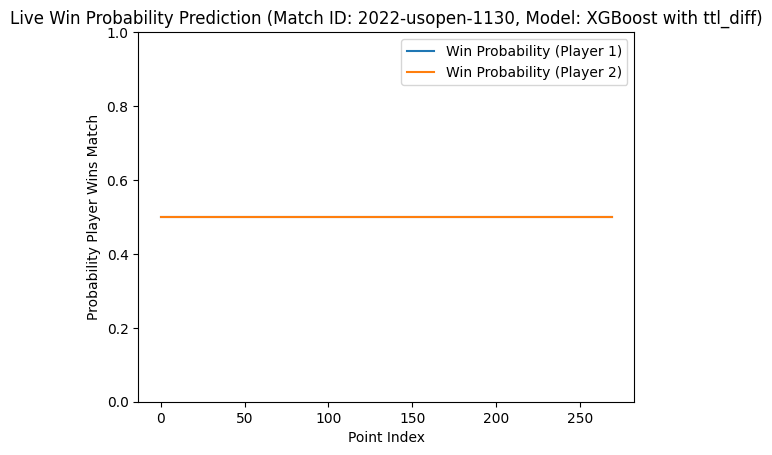

Log Loss: 0.6931471805599453
ROC AUC: 0.5


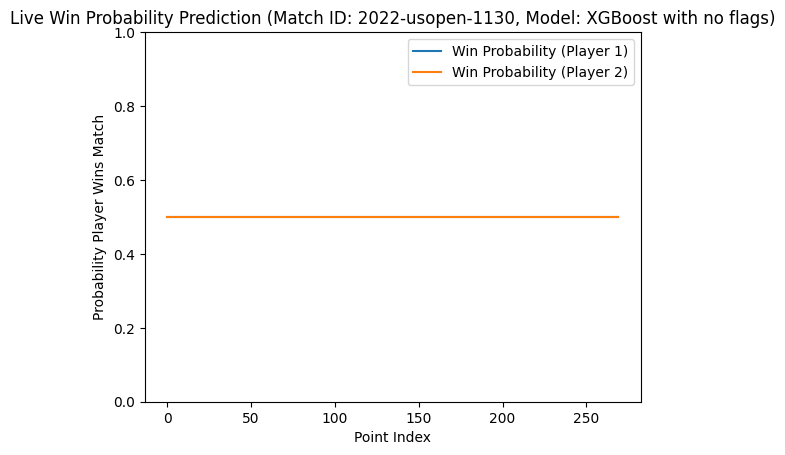

Log Loss: 0.25343159461121223
ROC AUC: 0.9988614540466393


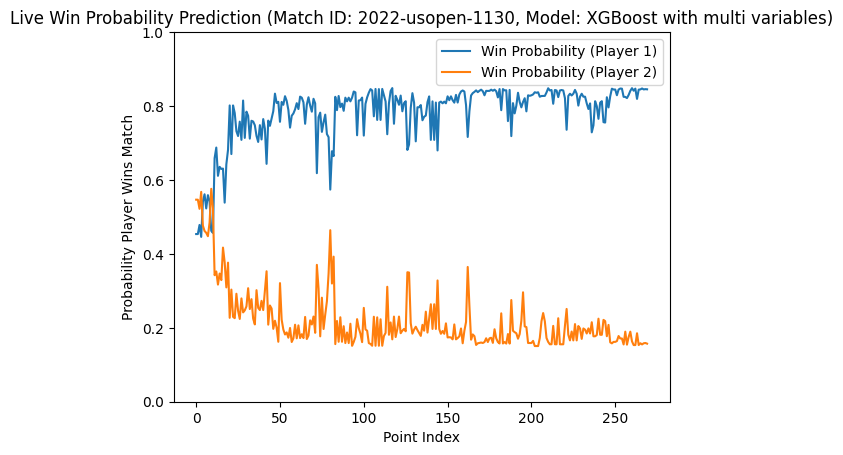

In [8]:
model_df = pd.read_parquet("model_data.parquet", engine="pyarrow")
for i in range(len(model_df)):
    model = XGBClassifier()
    model.load_model(model_df['model_path'][i])
    feature_cols = model_df['input_columns'][i].split('$')
    predict_win_probability(match_df, rand_id, model, feature_cols, model_df['model_desc'][i])

In [9]:
for i in match_df.columns:
    print((match_df[i]).head(1)) 


2763922    2022-usopen-1130
Name: match_id, dtype: object
2763922    1
Name: SetNo, dtype: Int64
2763922    1
Name: GameNo, dtype: Int64
2763922    500
Name: PointNumber, dtype: int16
2763922    1
Name: point_idx, dtype: int64
2763922    0.0
Name: time, dtype: float64
2763922    0.0
Name: elapsed_time, dtype: float64
2763922    False
Name: perspective, dtype: bool
2763922    False
Name: server_is_persp, dtype: bool
2763922    0
Name: pts_in_game_for, dtype: int64
2763922    0
Name: pts_in_game_against, dtype: int64
2763922    0
Name: games_in_set_for, dtype: int64
2763922    0
Name: games_in_set_against, dtype: int64
2763922    0
Name: sets_for, dtype: int64
2763922    0
Name: sets_against, dtype: int64
2763922    5
Name: best_of, dtype: int64
2763922    3
Name: sets_needed_to_win, dtype: int64
2763922    False
Name: is_tiebreak, dtype: bool
2763922    False
Name: is_game_point_for, dtype: bool
2763922    False
Name: is_game_point_against, dtype: bool
2763922    False
Name: is_break_po

In [10]:
(match_df['ss_in_pct_l60']).head(1)

2763922    0.0
Name: ss_in_pct_l60, dtype: float64